In [1]:
!pip install torch torchvision torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.4 MB/s eta 0:00:00


In [2]:
# LAB 8: PART A — Variational Autoencoder (VAE) + Latent Space
#         PART B — GAN for Image Synthesis (MNIST)
#         PART C — Graph Convolutional Network (GCN) on Cora
# ================================================================

# !pip install torch torchvision torch-geometric -q

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)


Device: cuda


In [3]:
# PART A: VARIATIONAL AUTOENCODER (VAE)
# Dataset: MNIST
# ================================================================
print("\n" + "="*60)
print("  PART A: VAE — Build + Visualize Latent Space")
print("="*60)



  PART A: VAE — Build + Visualize Latent Space


In [4]:
# A1. Data
# ----------------------------------------------------------------
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
mnist_test  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
test_loader  = DataLoader(mnist_test,  batch_size=256, shuffle=False)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.88MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.06MB/s]


In [5]:
# A2. VAE Model
# ----------------------------------------------------------------
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=2):
        super().__init__()
        # Encoder
        self.fc1    = nn.Linear(input_dim, hidden_dim)
        self.fc_mu  = nn.Linear(hidden_dim, latent_dim)   # mean
        self.fc_var = nn.Linear(hidden_dim, latent_dim)   # log variance

        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h    = F.relu(self.fc1(x))
        mu   = self.fc_mu(h)
        logv = self.fc_var(h)
        return mu, logv

    def reparameterize(self, mu, logv):
        # z = mu + eps * std   (reparameterization trick)
        std = torch.exp(0.5 * logv)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        x    = x.view(-1, 784)
        mu, logv = self.encode(x)
        z    = self.reparameterize(mu, logv)
        recon = self.decode(z)
        return recon, mu, logv

def vae_loss(recon_x, x, mu, logv):
    # Reconstruction loss (BCE) + KL divergence
    bce = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    kld = -0.5 * torch.sum(1 + logv - mu.pow(2) - logv.exp())
    return bce + kld


In [6]:
# A3. Train VAE
# ----------------------------------------------------------------
vae       = VAE(latent_dim=2).to(DEVICE)
opt_vae   = torch.optim.Adam(vae.parameters(), lr=1e-3)
VAE_EPOCHS = 10

vae_losses = []
print("Training VAE...")
for epoch in range(VAE_EPOCHS):
    vae.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(DEVICE)
        recon, mu, logv = vae(x)
        loss = vae_loss(recon, x, mu, logv)
        opt_vae.zero_grad(); loss.backward(); opt_vae.step()
        total_loss += loss.item()
    avg = total_loss / len(mnist_train)
    vae_losses.append(avg)
    print(f"  Epoch {epoch+1}/{VAE_EPOCHS} | loss: {avg:.4f}")


Training VAE...
  Epoch 1/10 | loss: 192.0588
  Epoch 2/10 | loss: 167.8386
  Epoch 3/10 | loss: 163.7035
  Epoch 4/10 | loss: 161.3551
  Epoch 5/10 | loss: 159.7268
  Epoch 6/10 | loss: 158.6066
  Epoch 7/10 | loss: 157.6196
  Epoch 8/10 | loss: 156.8899
  Epoch 9/10 | loss: 156.2348
  Epoch 10/10 | loss: 155.5994


(np.float64(-0.5), np.float64(241.5), np.float64(61.5), np.float64(-0.5))

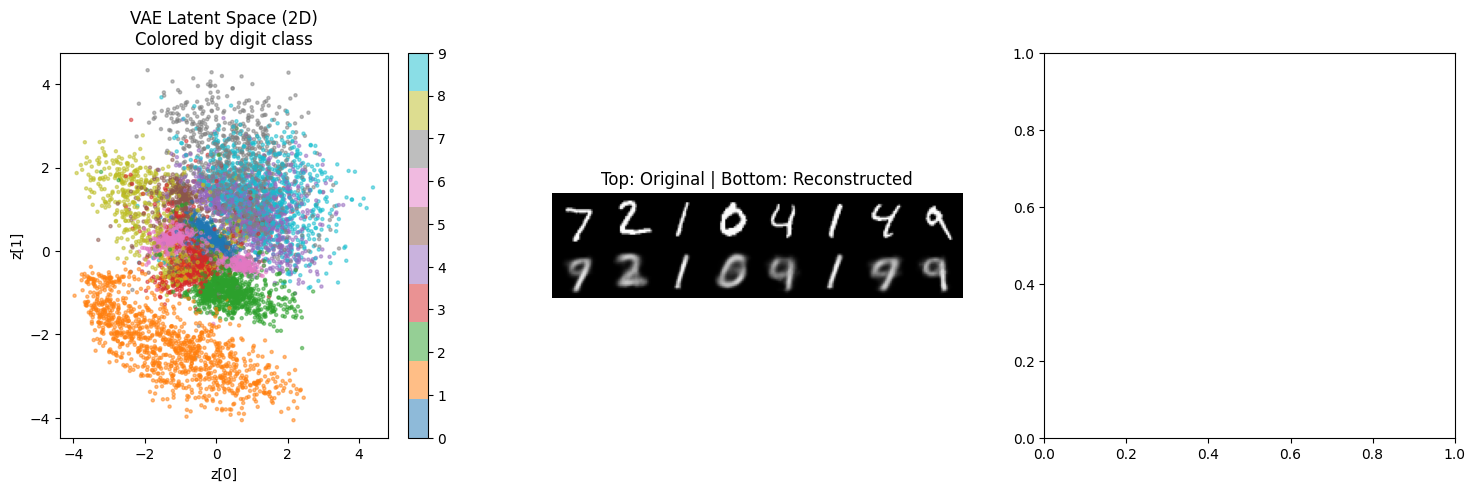

In [7]:
# A4. Visualize Latent Space
# ----------------------------------------------------------------
vae.eval()
all_z, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        mu, _ = vae.encode(x.to(DEVICE).view(-1, 784))
        all_z.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

all_z      = np.concatenate(all_z)
all_labels = np.concatenate(all_labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Latent space scatter
sc = axes[0].scatter(all_z[:,0], all_z[:,1], c=all_labels,
                     cmap='tab10', alpha=0.5, s=5)
plt.colorbar(sc, ax=axes[0])
axes[0].set_title('VAE Latent Space (2D)\nColored by digit class')
axes[0].set_xlabel('z[0]'); axes[0].set_ylabel('z[1]')

# Reconstruction
x_sample, _ = next(iter(test_loader))
x_sample = x_sample[:8].to(DEVICE)
with torch.no_grad():
    recon, _, _ = vae(x_sample)

orig  = x_sample.cpu().view(-1, 1, 28, 28)
recon = recon.cpu().view(-1, 1, 28, 28)
comparison = torch.cat([orig, recon])
grid = make_grid(comparison, nrow=8).permute(1,2,0).numpy()
axes[1].imshow(grid, cmap='gray')
axes[1].set_title('Top: Original | Bottom: Reconstructed')
axes[1].axis('off')


In [8]:
# Generated from random z
with torch.no_grad():
    z_random = torch.randn(64, 2).to(DEVICE)
    generated = vae.decode(z_random).cpu().view(-1, 1, 28, 28)
grid2 = make_grid(generated, nrow=8).permute(1,2,0).numpy()
axes[2].imshow(grid2, cmap='gray')
axes[2].set_title('Generated from Random z')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('lab8_vae.png', dpi=150)
plt.show()


<Figure size 640x480 with 0 Axes>

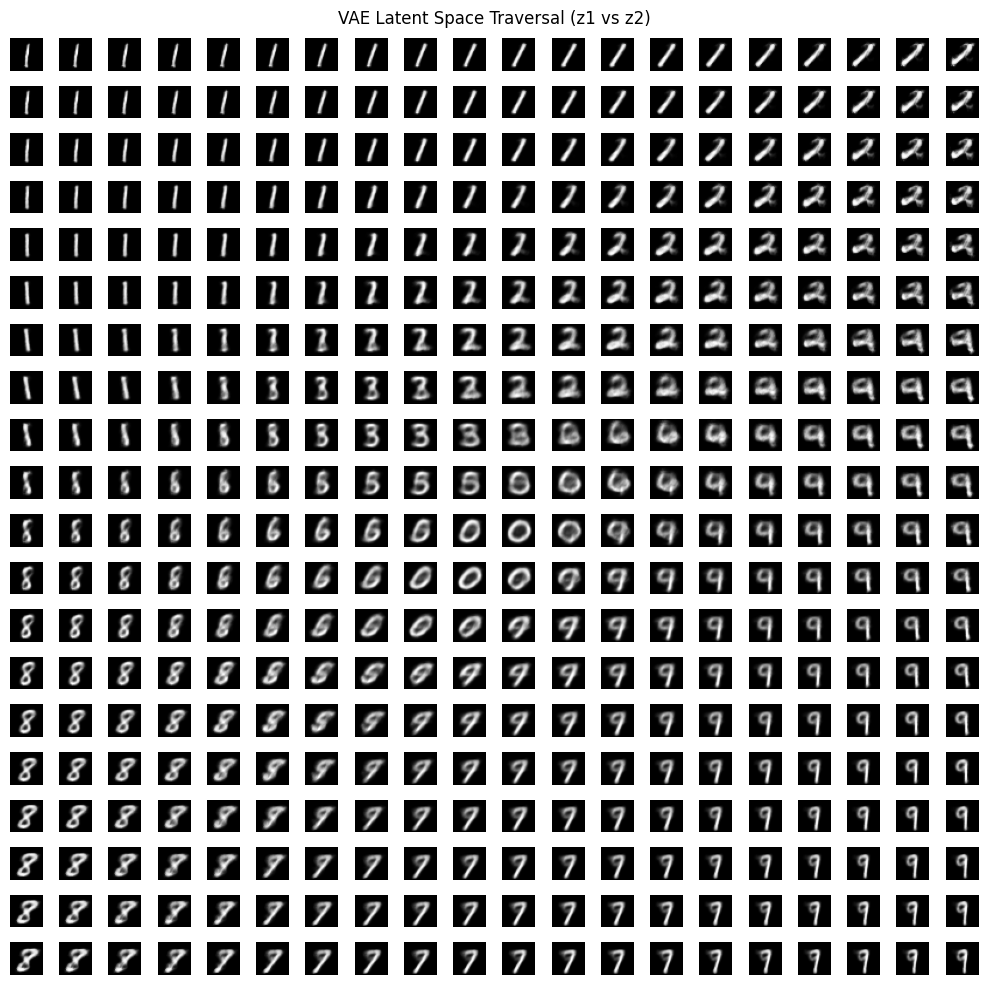

VAE done. Saved lab8_vae.png and lab8_vae_traversal.png


In [9]:
# Latent space traversal (2D grid)
fig, axes = plt.subplots(20, 20, figsize=(10, 10))
grid_x = np.linspace(-3, 3, 20)
grid_y = np.linspace(-3, 3, 20)
vae.eval()
with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(DEVICE)
            img = vae.decode(z).cpu().view(28, 28).numpy()
            axes[i][j].imshow(img, cmap='gray')
            axes[i][j].axis('off')

plt.suptitle('VAE Latent Space Traversal (z1 vs z2)', fontsize=12)
plt.tight_layout()
plt.savefig('lab8_vae_traversal.png', dpi=100)
plt.show()
print("VAE done. Saved lab8_vae.png and lab8_vae_traversal.png")


In [10]:
# ================================================================
# PART B: GAN for Image Synthesis (MNIST)
# ================================================================
print("\n" + "="*60)
print("  PART B: GAN — Train + Synthesize MNIST Images")
print("="*60)


  PART B: GAN — Train + Synthesize MNIST Images


In [11]:
# B1. Generator + Discriminator
# ----------------------------------------------------------------
LATENT_DIM = 100

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024),
            nn.Linear(1024, 784),
            nn.Tanh()            # output in [-1, 1]
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)

opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCELoss()


In [12]:
# GAN uses [-1,1] normalized data
gan_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
gan_loader = DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=gan_transform),
    batch_size=128, shuffle=True
)

In [13]:
# fixed noise to track progress
fixed_noise = torch.randn(64, LATENT_DIM).to(DEVICE)

In [14]:
# B2. Train GAN
# ----------------------------------------------------------------
GAN_EPOCHS = 20
G_losses, D_losses = [], []

print("Training GAN...")
for epoch in range(GAN_EPOCHS):
    g_loss_ep = d_loss_ep = 0
    for real_imgs, _ in gan_loader:
        real_imgs = real_imgs.view(-1, 784).to(DEVICE)
        bs = real_imgs.size(0)

        real_labels = torch.ones(bs, 1).to(DEVICE)
        fake_labels = torch.zeros(bs, 1).to(DEVICE)

        # ---- Train Discriminator ----
        z         = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake_imgs = G(z).detach()

        d_real = criterion(D(real_imgs), real_labels)
        d_fake = criterion(D(fake_imgs), fake_labels)
        d_loss = d_real + d_fake

        opt_D.zero_grad(); d_loss.backward(); opt_D.step()

        # ---- Train Generator ----
        z         = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake_imgs = G(z)
        g_loss    = criterion(D(fake_imgs), real_labels)  # fool D

        opt_G.zero_grad(); g_loss.backward(); opt_G.step()

        g_loss_ep += g_loss.item()
        d_loss_ep += d_loss.item()

    G_losses.append(g_loss_ep / len(gan_loader))
    D_losses.append(d_loss_ep / len(gan_loader))
    print(f"  Epoch {epoch+1:2d}/{GAN_EPOCHS} | D_loss: {D_losses[-1]:.4f} | G_loss: {G_losses[-1]:.4f}")


Training GAN...
  Epoch  1/20 | D_loss: 0.8591 | G_loss: 1.1411
  Epoch  2/20 | D_loss: 1.2521 | G_loss: 0.8269
  Epoch  3/20 | D_loss: 1.2539 | G_loss: 0.8555
  Epoch  4/20 | D_loss: 1.2760 | G_loss: 0.8400
  Epoch  5/20 | D_loss: 1.2876 | G_loss: 0.8234
  Epoch  6/20 | D_loss: 1.3091 | G_loss: 0.8007
  Epoch  7/20 | D_loss: 1.3202 | G_loss: 0.7829
  Epoch  8/20 | D_loss: 1.3308 | G_loss: 0.7737
  Epoch  9/20 | D_loss: 1.3382 | G_loss: 0.7639
  Epoch 10/20 | D_loss: 1.3495 | G_loss: 0.7520
  Epoch 11/20 | D_loss: 1.3540 | G_loss: 0.7480
  Epoch 12/20 | D_loss: 1.3561 | G_loss: 0.7446
  Epoch 13/20 | D_loss: 1.3584 | G_loss: 0.7406
  Epoch 14/20 | D_loss: 1.3622 | G_loss: 0.7385
  Epoch 15/20 | D_loss: 1.3639 | G_loss: 0.7358
  Epoch 16/20 | D_loss: 1.3644 | G_loss: 0.7363
  Epoch 17/20 | D_loss: 1.3641 | G_loss: 0.7370
  Epoch 18/20 | D_loss: 1.3647 | G_loss: 0.7367
  Epoch 19/20 | D_loss: 1.3663 | G_loss: 0.7338
  Epoch 20/20 | D_loss: 1.3668 | G_loss: 0.7347


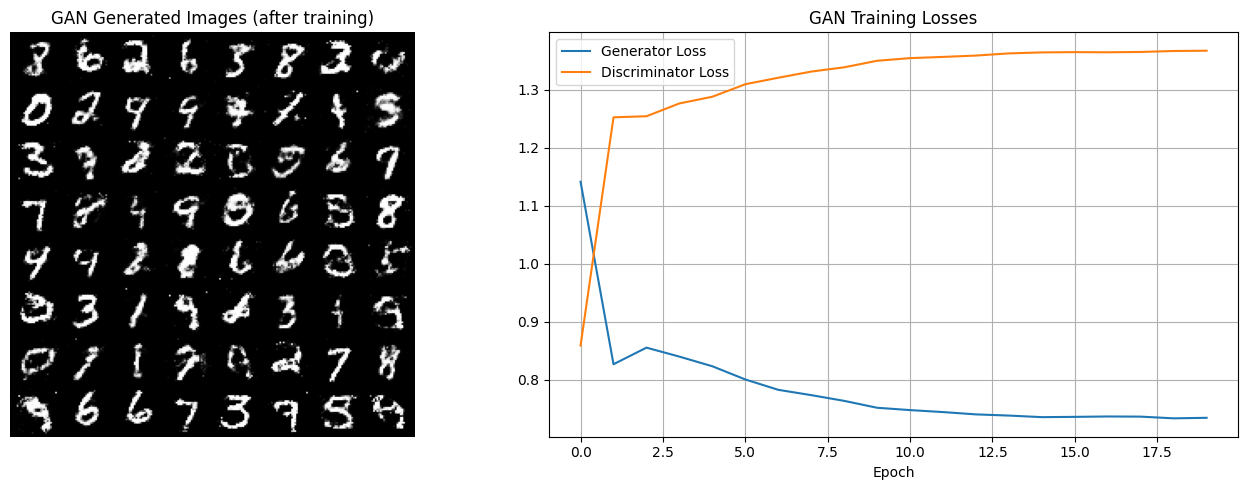

GAN done. Saved lab8_gan.png


In [15]:
# B3. Visualize GAN output
# ----------------------------------------------------------------
G.eval()
with torch.no_grad():
    fake = G(fixed_noise).cpu().view(-1, 1, 28, 28)
    fake = (fake + 1) / 2   # [-1,1] → [0,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
grid = make_grid(fake, nrow=8).permute(1,2,0).numpy()
axes[0].imshow(grid, cmap='gray')
axes[0].set_title('GAN Generated Images (after training)')
axes[0].axis('off')

axes[1].plot(G_losses, label='Generator Loss')
axes[1].plot(D_losses, label='Discriminator Loss')
axes[1].set_title('GAN Training Losses')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('lab8_gan.png', dpi=150)
plt.show()
print("GAN done. Saved lab8_gan.png")


In [16]:
# PART C: Graph Convolutional Network (GCN) on Cora Dataset
# ================================================================
print("\n" + "="*60)
print("  PART C: GCN on Cora Citation Dataset")
print("="*60)

try:
    from torch_geometric.datasets import Planetoid
    from torch_geometric.nn import GCNConv
    import torch_geometric.transforms as T
    GEO_AVAILABLE = True
except ImportError:
    GEO_AVAILABLE = False
    print("torch_geometric not found — using manual GCN implementation")

if GEO_AVAILABLE:
    # ----------------------------------------------------------------
    # C1. Load Cora
    # ----------------------------------------------------------------
    dataset = Planetoid(root='./data', name='Cora',
                        transform=T.NormalizeFeatures())
    data    = dataset[0].to(DEVICE)

    print(f"Nodes    : {data.num_nodes}")
    print(f"Edges    : {data.num_edges}")
    print(f"Features : {data.num_node_features}")
    print(f"Classes  : {dataset.num_classes}")
    print(f"Train/Val/Test: {data.train_mask.sum()}/{data.val_mask.sum()}/{data.test_mask.sum()}")



  PART C: GCN on Cora Citation Dataset


Processing...


Nodes    : 2708
Edges    : 10556
Features : 1433
Classes  : 7
Train/Val/Test: 140/500/1000


Done!


In [23]:
 # ----------------------------------------------------------------
    # C2. GCN Model
    # ---------------------------------------------------------------
class GCN(nn.Module):
        def __init__(self, in_ch, hidden_ch, out_ch, dropout=0.5):
            super().__init__()
            self.conv1   = GCNConv(in_ch, hidden_ch)
            self.conv2   = GCNConv(hidden_ch, out_ch)
            self.dropout = dropout

        def forward(self, x, edge_index):
            x = F.relu(self.conv1(x, edge_index))
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = self.conv2(x, edge_index)
            return F.log_softmax(x, dim=1)

gcn     = GCN(dataset.num_node_features, 64, dataset.num_classes).to(DEVICE)
opt_gcn = torch.optim.Adam(gcn.parameters(), lr=0.01, weight_decay=5e-4)


In [32]:
# ----------------------------------------------------------------
# C3. Train GCN
# ----------------------------------------------------------------

GCN_EPOCHS = 200

train_accs = []
val_accs = []
train_losses_c = []

print("Training GCN...")

for epoch in range(GCN_EPOCHS):

    # ---------------- TRAINING ----------------
    gcn.train()

    opt_gcn.zero_grad()

    # Forward pass
    out = gcn(data.x, data.edge_index)

    # Loss calculation
    loss = F.nll_loss(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    # Backpropagation
    loss.backward()

    # Update weights
    opt_gcn.step()

    # ---------------- EVALUATION ----------------
    gcn.eval()

    with torch.no_grad():

        out = gcn(data.x, data.edge_index)

        pred = out.argmax(dim=1)

        # Training Accuracy
        t_acc = (
            (pred[data.train_mask] == data.y[data.train_mask])
            .float()
            .mean()
            .item()
        )

        # Validation Accuracy
        v_acc = (
            (pred[data.val_mask] == data.y[data.val_mask])
            .float()
            .mean()
            .item()
        )

    # Store metrics
    train_losses_c.append(loss.item())
    train_accs.append(t_acc)
    val_accs.append(v_acc)

    # Print progress every 50 epochs
    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch {epoch+1:3d} | "
            f"Loss: {loss.item():.4f} | "
            f"Train Acc: {t_acc:.4f} | "
            f"Val Acc: {v_acc:.4f}"
        )

Training GCN...
Epoch  50 | Loss: 0.4973 | Train Acc: 0.9857 | Val Acc: 0.8120
Epoch 100 | Loss: 0.2559 | Train Acc: 1.0000 | Val Acc: 0.7960
Epoch 150 | Loss: 0.1874 | Train Acc: 1.0000 | Val Acc: 0.7840
Epoch 200 | Loss: 0.1695 | Train Acc: 1.0000 | Val Acc: 0.7980


In [35]:
# ----------------------------------------------------------------
# Test Accuracy
# ----------------------------------------------------------------

gcn.eval()

with torch.no_grad():

    # Forward pass
    out = gcn(data.x, data.edge_index)

    # Predicted classes
    pred = out.argmax(dim=1)

    # Test accuracy calculation
    test_acc = (
        (pred[data.test_mask] == data.y[data.test_mask])
        .float()
        .mean()
        .item()
    )

print(f"\nFinal Test Accuracy: {test_acc:.4f}")


Final Test Accuracy: 0.8080


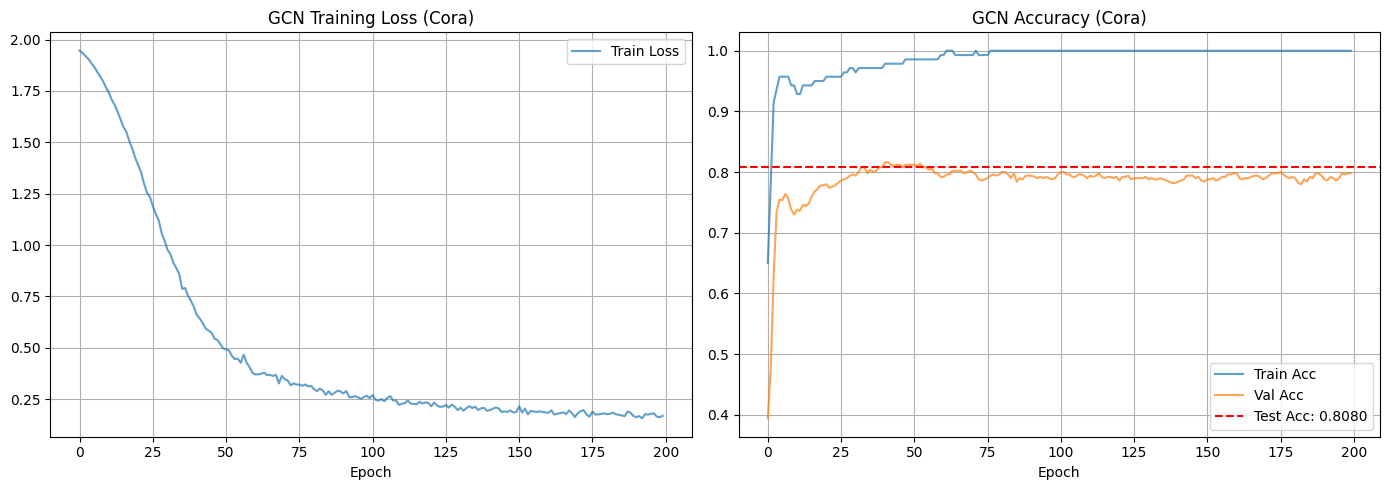


Running manual GCN on synthetic graph data...


In [43]:
# C4. Plot GCN results
# ----------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses_c, label='Train Loss', alpha=0.7)
axes[0].set_title('GCN Training Loss (Cora)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_accs, label='Train Acc', alpha=0.7)
axes[1].plot(val_accs, label='Val Acc', alpha=0.7)

axes[1].axhline(
    test_acc,
    color='red',
    linestyle='--',
    label=f'Test Acc: {test_acc:.4f}'
)

axes[1].set_title('GCN Accuracy (Cora)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('lab8_gcn.png', dpi=150)
plt.show()

# ----------------------------------------------------------------
# FALLBACK: Manual GCN without torch_geometric
# ----------------------------------------------------------------

print("\nRunning manual GCN on synthetic graph data...")

# synthetic adjacency + features
N, F_in, C = 200, 16, 7

np.random.seed(42)

A = np.random.randint(0, 2, (N, N)).astype(np.float32)

A = np.maximum(A, A.T)   # symmetric

np.fill_diagonal(A, 1)   # self-loops

D_inv = np.diag(1.0 / A.sum(axis=1))

A_norm = torch.tensor(
    D_inv @ A,
    dtype=torch.float32
).to(DEVICE)

X = torch.randn(N, F_in).to(DEVICE)

labels = torch.randint(0, C, (N,)).to(DEVICE)

train_mask = torch.zeros(N, dtype=torch.bool)

train_mask[:140] = True

test_mask = ~train_mask

Epoch 50 | loss: 1.9229 | test_acc: 0.1167
Epoch 100 | loss: 1.9191 | test_acc: 0.1167
Epoch 150 | loss: 1.8991 | test_acc: 0.1167
Epoch 200 | loss: 1.8522 | test_acc: 0.1000


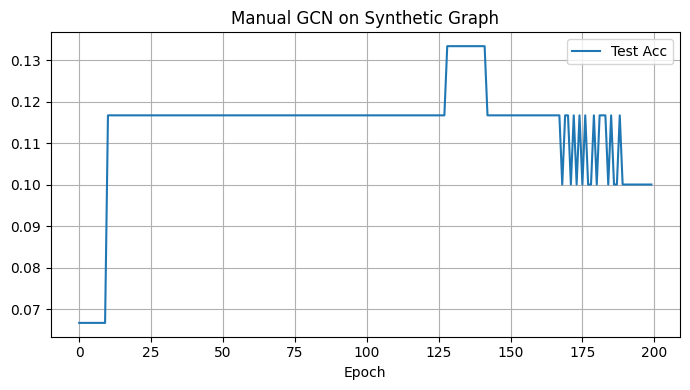


All parts done!


In [48]:
class ManualGCN(nn.Module):

    def __init__(self):
        super().__init__()

        self.W1 = nn.Linear(F_in, 32, bias=False)
        self.W2 = nn.Linear(32, C, bias=False)

    def forward(self, x, a):

        # GCN formula:
        # H = A_norm * ReLU(A_norm * X * W1) * W2

        x = F.relu(self.W1(a @ x))
        x = self.W2(a @ x)

        return F.log_softmax(x, dim=1)


mgcn = ManualGCN().to(DEVICE)

opt_m = torch.optim.Adam(
    mgcn.parameters(),
    lr=0.01
)

m_accs = []

for epoch in range(200):

    mgcn.train()

    out = mgcn(X, A_norm)

    loss = F.nll_loss(
        out[train_mask],
        labels[train_mask]
    )

    opt_m.zero_grad()

    loss.backward()

    opt_m.step()

    mgcn.eval()

    with torch.no_grad():

        pred = mgcn(X, A_norm).argmax(dim=1)

        t_acc = (
            (pred[test_mask] == labels[test_mask])
            .float()
            .mean()
            .item()
        )

    m_accs.append(t_acc)

    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch {epoch+1} | "
            f"loss: {loss.item():.4f} | "
            f"test_acc: {t_acc:.4f}"
        )

plt.figure(figsize=(7, 4))

plt.plot(m_accs, label='Test Acc')

plt.title('Manual GCN on Synthetic Graph')

plt.xlabel('Epoch')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig('lab8_gcn.png', dpi=150)

plt.show()

print("\nAll parts done!")